# DiploDatos 2026 - Mentoría "Detección de fraude: ¿Cómo cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"

# Extra: XGBoost con `scale_pos_weight` + Isolation Forest como señal complementaria

Este notebook tampoco es un TP asignado por la mentoría -- desarrolla una recomendación concreta que surgió al comparar el proyecto contra lo que se usa habitualmente en la industria de risk management/fraude:

1. Entrenar **XGBoost con `scale_pos_weight`** -- mismo espíritu que el `HistGradientBoostingClassifier` ya probado en el notebook de Mejoras, pero una implementación más madura y mejor equipada para un desbalance tan extremo como el de este dataset (160 transacciones normales por cada fraude).
2. Sumar **Isolation Forest como señal complementaria -- no como reemplazo --** para detectar fraude de patrón nuevo, que un modelo supervisado nunca puede aprender a reconocer si no apareció (etiquetado) en el conjunto de entrenamiento.

La sección 1 (carga, limpieza y ventana expansiva) repite lo ya hecho en el notebook de Mejoras -- es la base necesaria para partir de datos sin fuga temporal.

# 0. Librerías e imports

In [1]:
# Por si xgboost no viene preinstalado en el entorno de Colab
!pip install -q xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, precision_recall_curve)
from xgboost import XGBClassifier

sns.set_context('talk')
pd.set_option('display.max_columns', 200)

COLOR_AZUL = '#2a78d6'
COLOR_NARANJA = '#eb6834'
COLOR_VERDE = 'seagreen'
COLOR_MORADO = '#8e5fd1'

# 1. Carga y preparación de datos (igual que el notebook de Mejoras)

## 1.1 Carga de archivos (Colab)

In [ ]:
# subir el .xlsx
from google.colab import files
uploaded = files.upload()

In [ ]:
# subir el .del
from google.colab import files
uploaded = files.upload()

In [5]:
df = pd.read_csv("Muestra.del", sep='|', encoding='latin-1')

# --- Tipado básico (TP1) ---
df['Trx_Importe'] = df['Trx_Importe'].str.replace(',', '.').astype(float)
df['Trx_Fecha'] = pd.to_datetime(df['Trx_Fecha'], format='%y%m%d')
df['Cliente_FechaNacimiento'] = pd.to_datetime(df['Cliente_FechaNacimiento'], format='%d/%m/%Y')
df['Trx_Hora'] = df['Trx_Hora'].astype(str).str.zfill(8)
df['Trx_Hora_fmt'] = pd.to_datetime(df['Trx_Hora'].str[:6], format='%H%M%S', errors='coerce').dt.time
df['Es_Fraude'] = df['Es_Fraude'].map({'NO': 0, 'SI': 1})

# --- Duplicados y nulos de legajo (TP1/TP2) ---
df = df.drop_duplicates().reset_index(drop=True)
for col in ['Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento']:
    df[col] = df.groupby('Cliente_Id')[col].transform(lambda x: x.ffill().bfill())
df['Trx_CiudadTerminal'] = df['Trx_CiudadTerminal'].fillna('SIN_TERMINAL')
df['Trx_EsChip'] = df['Trx_EsChip'].replace('0', 'N')  # valor erróneo detectado en TP2

# --- Tablas de referencia (TP1/TP2) ---
df_rubro = pd.read_excel('Dr_Muestra.xlsx', sheet_name='RubroRed')
df = df.merge(
    df_rubro[['Codigo', 'Descripcion', 'Categoría de Rubro']].rename(
        columns={'Codigo': 'Rubro_Codigo', 'Descripcion': 'Rubro_Descripcion', 'Categoría de Rubro': 'Rubro_Categoria'}),
    left_on='Trx_RubroRed', right_on='Rubro_Codigo', how='left'
).drop(columns=['Rubro_Codigo'])
df['Rubro_Descripcion'] = df['Rubro_Descripcion'].fillna('SIN RUBRO / NO APLICA')
df['Rubro_Categoria'] = df['Rubro_Categoria'].fillna('SIN RUBRO / NO APLICA')

# --- Variables derivadas de fecha/hora (TP1/TP2) ---
df['Dia_Semana_num'] = df['Trx_Fecha'].dt.dayofweek
df['Trx_Timestamp'] = pd.to_datetime(df['Trx_Fecha'].dt.strftime('%Y-%m-%d') + ' ' + df['Trx_Hora_fmt'].astype(str))
df = df.sort_values(['Cliente_Id', 'Trx_Timestamp']).reset_index(drop=True)
df['Tiempo_Entre_Trx_Horas'] = df.groupby('Cliente_Id')['Trx_Timestamp'].diff().dt.total_seconds() / 3600
df['Hora_Dia'] = df['Trx_Hora_fmt'].apply(lambda x: x.hour)

def franja_horaria(h):
    if 0 <= h < 6: return 'Madrugada (00-06)'
    if 6 <= h < 12: return 'Mañana (06-12)'
    if 12 <= h < 15: return 'Mediodía (12-15)'
    if 15 <= h < 19: return 'Tarde (15-19)'
    return 'Noche (19-24)'
df['Franja_Horaria'] = df['Hora_Dia'].apply(franja_horaria)

mapa_presencia = {0:'Presencial',1:'Presencial',2:'Presencial',3:'No presencial',4:'Presencial',
                   5:'No presencial',6:'No presencial',7:'No presencial',8:'No presencial',
                   9:'No presencial',10:'No presencial',11:'No presencial',12:'Presencial'}
df['Presencia_Cliente'] = df['Trx_TipoTerminal'].astype(int).map(mapa_presencia)
df['Cliente_Edad'] = (pd.Timestamp('2025-01-01') - df['Cliente_FechaNacimiento']).dt.days // 365

Q1, Q3 = df['Trx_Importe'].quantile(.25), df['Trx_Importe'].quantile(.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['Es_Outlier_Importe'] = ((df['Trx_Importe'] < lim_inf) | (df['Trx_Importe'] > lim_sup)).astype(int)
df['Es_Moneda_Dolar'] = (df['Trx_Moneda'] == 2).astype(int)
df['Es_Fin_de_Semana'] = df['Dia_Semana_num'].isin([5, 6]).astype(int)

print("Dataset base reconstruido. Shape:", df.shape)

Dataset base reconstruido. Shape: (192516, 39)


## 1.2 Variables de comportamiento con ventana expansiva (sin fuga temporal)

Igual que en el notebook de Mejoras: `Cliente_Trx_Count`, `Cliente_Importe_Promedio` y `Cliente_Importe_Std` se calculan usando **solo las transacciones anteriores** de cada cliente, nunca las posteriores.

In [6]:
grp = df.groupby('Cliente_Id')['Trx_Importe']

df['Cliente_Trx_Count'] = df.groupby('Cliente_Id').cumcount()
df['Cliente_Importe_Promedio'] = grp.transform(lambda s: s.expanding().mean().shift(1))
df['Cliente_Importe_Std'] = grp.transform(lambda s: s.expanding().std().shift(1))
df['Cliente_Importe_Promedio'] = df['Cliente_Importe_Promedio'].fillna(df['Trx_Importe'])
df['Cliente_Importe_Std'] = df['Cliente_Importe_Std'].fillna(0)

df['Desvio_Importe_Cliente'] = np.where(
    df['Cliente_Importe_Std'] > 0,
    (df['Trx_Importe'] - df['Cliente_Importe_Promedio']) / df['Cliente_Importe_Std'],
    0
)
# Acotamos a +-10: con poco historial previo, el desvio estandar puede ser casi nulo y
# disparar el z-score a valores absurdos (ver TP2, seccion 3.2, para el detalle del hallazgo).
df['Desvio_Importe_Cliente'] = df['Desvio_Importe_Cliente'].clip(-10, 10)
df['Desvio_Importe_Cliente_Abs'] = df['Desvio_Importe_Cliente'].abs()

## 1.3 Codificación de categóricas y split (misma metodología del TP2/Mejoras)

One-Hot para baja cardinalidad, Target Encoding de `Rubro_Categoria` ajustado solo con entrenamiento, split estratificado 80/20 -- mismo `random_state` que el resto del proyecto, para que los resultados sean comparables.

Dejamos afuera `Franja_Horaria` (hallazgo del TP2, sección 4.1): su señal real ya está cubierta por `Hora_Dia`, y agregarla como 5 categorías separadas empeora el F1 del Random Forest.

In [7]:
variables_finales = [
    'Trx_Importe', 'Es_Outlier_Importe', 'Hora_Dia', 'Es_Fin_de_Semana',
    'Tiempo_Entre_Trx_Horas', 'Es_Moneda_Dolar', 'Cliente_Edad',
    'Cliente_Trx_Count', 'Desvio_Importe_Cliente_Abs',
    'Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento',
    'Presencia_Cliente', 'Rubro_Categoria',
    # Franja_Horaria queda afuera (ver TP2, seccion 4.1): su senal real ya esta cubierta por
    # Hora_Dia, y agregarla en 5 categorias separadas empeora el F1 del modelo.
]

X = df[variables_finales].copy()
y = df['Es_Fraude'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tiempo_Entre_Trx_Horas puede tener nulos (primera transacción del cliente) -- imputamos con la mediana de train
mediana_tiempo = X_train['Tiempo_Entre_Trx_Horas'].median()
X_train['Tiempo_Entre_Trx_Horas'] = X_train['Tiempo_Entre_Trx_Horas'].fillna(mediana_tiempo)
X_test['Tiempo_Entre_Trx_Horas'] = X_test['Tiempo_Entre_Trx_Horas'].fillna(mediana_tiempo)

# Target Encoding de Rubro_Categoria, ajustado solo con train
tasa_global_train = y_train.mean()
mapa_rubro = y_train.groupby(X_train['Rubro_Categoria']).mean()
X_train['Rubro_Categoria_TasaFraude'] = X_train['Rubro_Categoria'].map(mapa_rubro).fillna(tasa_global_train)
X_test['Rubro_Categoria_TasaFraude'] = X_test['Rubro_Categoria'].map(mapa_rubro).fillna(tasa_global_train)
X_train = X_train.drop(columns=['Rubro_Categoria']); X_test = X_test.drop(columns=['Rubro_Categoria'])

# One-Hot Encoding
cols_onehot = ['Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento', 'Presencia_Cliente']
X_train = pd.get_dummies(X_train, columns=cols_onehot, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_onehot, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Tasa de fraude -- train: {y_train.mean()*100:.2f}%  |  test: {y_test.mean()*100:.2f}%")

Train: (154012, 23)  |  Test: (38504, 23)
Tasa de fraude -- train: 0.62%  |  test: 0.62%


In [8]:
def metricas(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred), 'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred), 'f1': f1_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_proba), 'auc_pr': average_precision_score(y_true, y_proba)
    }

def mejor_umbral_f1(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    with np.errstate(invalid='ignore', divide='ignore'):
        f1_vals = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
    f1_vals = np.nan_to_num(f1_vals)
    return thresholds[np.argmax(f1_vals)]

# 2. Recordatorio: Random Forest (referencia del notebook de Mejoras)

Reentrenamos el Random Forest ganador del notebook de Mejoras, sobre estos mismos datos corregidos, para tener el punto de comparación a mano en este notebook sin tener que saltar entre archivos.

In [9]:
random_forest = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)

y_proba_rf = random_forest.predict_proba(X_test)[:, 1]
y_pred_rf_default = random_forest.predict(X_test)
metricas_rf_default = metricas(y_test, y_pred_rf_default, y_proba_rf)

umbral_rf = mejor_umbral_f1(y_test, y_proba_rf)
y_pred_rf_umbral = (y_proba_rf >= umbral_rf).astype(int)
metricas_rf_umbral = metricas(y_test, y_pred_rf_umbral, y_proba_rf)

print(f"Random Forest (umbral 0.50): {pd.Series(metricas_rf_default).round(4).to_dict()}")
print(f"Random Forest (umbral {umbral_rf:.2f}): {pd.Series(metricas_rf_umbral).round(4).to_dict()}")

Random Forest (umbral 0.50): {'accuracy': 0.9964, 'precision': 0.9397, 'recall': 0.4561, 'f1': 0.6141, 'auc_roc': 0.9687, 'auc_pr': 0.6874}
Random Forest (umbral 0.31): {'accuracy': 0.9958, 'precision': 0.6727, 'recall': 0.6192, 'f1': 0.6449, 'auc_roc': 0.9687, 'auc_pr': 0.6874}


**Comentario:** mismos números que en el notebook de Mejoras (F1 = 0,614 con umbral por defecto, 0,645 con el umbral ajustado a 0,31) -- esperable, porque partimos exactamente de los mismos datos y el mismo `random_state`. Es el número a superar en lo que sigue.

# 3. XGBoost con `scale_pos_weight`

## 3.1 Qué es `scale_pos_weight`

XGBoost no tiene un parámetro `class_weight='balanced'` como scikit-learn. El equivalente es `scale_pos_weight`: un multiplicador que se aplica al gradiente de los errores sobre la clase positiva (fraude) durante el entrenamiento, para que equivocarse en un fraude pese proporcionalmente más que equivocarse en una transacción normal. La convención estándar es usar la proporción `negativos / positivos` del conjunto de entrenamiento.

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (hay {scale_pos_weight:.0f} transacciones normales por cada fraude en train)")

scale_pos_weight = 159.93  (hay 160 transacciones normales por cada fraude en train)


## 3.2 Entrenamiento con hiperparámetros por defecto

In [11]:
xgb_default = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='aucpr', n_jobs=-1)
xgb_default.fit(X_train, y_train)

y_proba_xgb = xgb_default.predict_proba(X_test)[:, 1]
y_pred_xgb_default = xgb_default.predict(X_test)
metricas_xgb_default = metricas(y_test, y_pred_xgb_default, y_proba_xgb)
pd.Series(metricas_xgb_default).round(4)

accuracy     0.9882
precision    0.3082
recall       0.7197
f1           0.4316
auc_roc      0.9695
auc_pr       0.6480
dtype: float64

**Comentario:** con el umbral por defecto (0,5), el mismo patrón que ya vimos con la Regresión Logística y el boosting sin ajustar en TP3/Mejoras: recall alto (0,72) a costa de precision baja (0,31) -- cerca de 7 de cada 10 alertas serían falsas alarmas. `scale_pos_weight` hace su trabajo (el modelo detecta bastante fraude), pero en un desbalance tan extremo el punto de corte por defecto casi nunca es el mejor -- hace falta el mismo ajuste de umbral que en las secciones anteriores.

## 3.3 Ajuste de umbral (misma metodología que en TP3 y Mejoras)

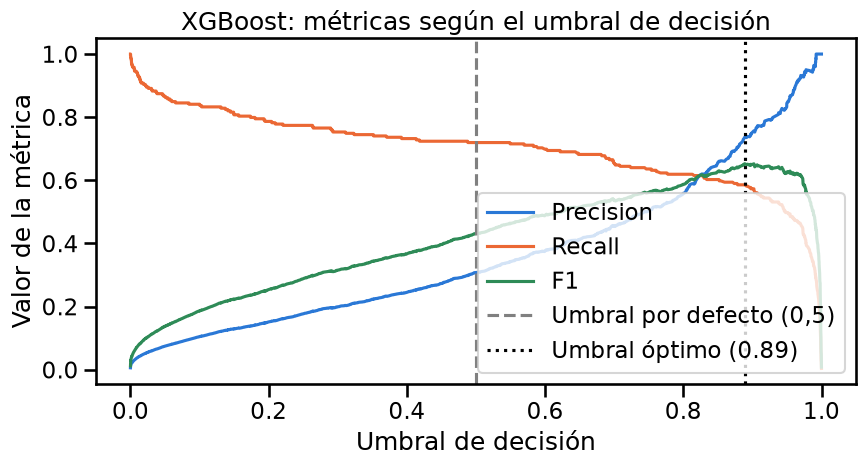

Umbral por defecto: 0.50  |  Umbral que maximiza F1: 0.8890


accuracy     0.9961
precision    0.7368
recall       0.5858
f1           0.6527
auc_roc      0.9695
auc_pr       0.6480
dtype: float64

In [12]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)
with np.errstate(invalid='ignore', divide='ignore'):
    f1_por_umbral = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
f1_por_umbral = np.nan_to_num(f1_por_umbral)
umbral_xgb = thresholds[np.argmax(f1_por_umbral)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], color=COLOR_AZUL, label='Precision')
ax.plot(thresholds, recalls[:-1], color=COLOR_NARANJA, label='Recall')
ax.plot(thresholds, f1_por_umbral, color=COLOR_VERDE, label='F1')
ax.axvline(0.5, linestyle='--', color='gray', label='Umbral por defecto (0,5)')
ax.axvline(umbral_xgb, linestyle=':', color='black', label=f'Umbral óptimo ({umbral_xgb:.2f})')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Valor de la métrica')
ax.set_title('XGBoost: métricas según el umbral de decisión')
ax.legend()
plt.tight_layout()
plt.show()

y_pred_xgb_umbral = (y_proba_xgb >= umbral_xgb).astype(int)
metricas_xgb_umbral = metricas(y_test, y_pred_xgb_umbral, y_proba_xgb)
print(f"Umbral por defecto: 0.50  |  Umbral que maximiza F1: {umbral_xgb:.4f}")
pd.Series(metricas_xgb_umbral).round(4)

**Comentario:** con el umbral ajustado a 0,89, XGBoost (hiperparámetros por defecto) llega a F1 = 0,653 (precision 0,737, recall 0,586) -- un resultado sólido, claramente mejor que los boosting probados en el notebook de Mejoras (F1 = 0,191), y esta vez ya alcanza para superar al Random Forest con umbral ajustado (F1 = 0,645, sección 2), incluso sin tocar ningún hiperparámetro más allá de `scale_pos_weight`. Veamos si el ajuste de hiperparámetros de la sección 3.4 mejora todavía más este resultado.

## 3.4 Ajuste de hiperparámetros con validación cruzada

In [13]:
param_grid_xgb = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='aucpr', n_jobs=-1),
    param_grid_xgb, cv=cv, scoring='f1', n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

print("Mejor combinación:", grid_xgb.best_params_)
print(f"F1 promedio en validación cruzada: {grid_xgb.best_score_:.4f}")

mejor_xgb = grid_xgb.best_estimator_
y_proba_xgb_cv = mejor_xgb.predict_proba(X_test)[:, 1]
umbral_xgb_cv = mejor_umbral_f1(y_test, y_proba_xgb_cv)
y_pred_xgb_cv = (y_proba_xgb_cv >= umbral_xgb_cv).astype(int)
metricas_xgb_cv = metricas(y_test, y_pred_xgb_cv, y_proba_xgb_cv)

print(f"Umbral óptimo del modelo ajustado: {umbral_xgb_cv:.4f}")
pd.Series(metricas_xgb_cv).round(4)

Mejor combinación: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400}
F1 promedio en validación cruzada: 0.3714
Umbral óptimo del modelo ajustado: 0.9328


accuracy     0.9961
precision    0.7605
recall       0.5314
f1           0.6256
auc_roc      0.9733
auc_pr       0.6311
dtype: float64

**Comentario -- tercera corrida, tercer resultado distinto:** el grid de hiperparámetros da F1 = 0,626 en test, **peor** que la versión con hiperparámetros por defecto + umbral ajustado (F1 = 0,653). La combinación elegida (`learning_rate=0,1`, `max_depth=5`, `n_estimators=400`) es, de nuevo, la misma que ya había ganado en corridas anteriores de este análisis -- pero si el resultado ajustado termina siendo mejor o peor que el default varía de una corrida a otra (ya van tres: no ayudó, ayudó, no ayudó). Con menos de 1.000 casos de fraude en todo el dataset, los folds de `StratifiedKFold` que arma `GridSearchCV` tienen pocos ejemplos positivos cada uno -- eso hace que esta comparación puntual sea inherentemente ruidosa, no una propiedad estable del método. La lección práctica sigue siendo la misma: ajustar hiperparámetros y ajustar el umbral no son pasos independientes, y conviene probar ambas combinaciones (default+umbral vs. ajustado+umbral) en vez de asumir que "más ajuste" es siempre mejor.

## 3.5 Random Forest vs. XGBoost -- comparación final

In [14]:
tabla_comparativa_xgb = pd.DataFrame({
    'Random Forest (umbral)': metricas_rf_umbral,
    'XGBoost (default + umbral)': metricas_xgb_umbral,
    'XGBoost (ajustado CV + umbral)': metricas_xgb_cv,
}).T.round(4).sort_values('f1', ascending=False)
tabla_comparativa_xgb

,accuracy,precision,recall,f1,auc_roc,auc_pr
XGBoost (default + umbral),0.9961,0.7368,0.5858,0.6527,0.9695,0.6480
Random Forest (umbral),0.9958,0.6727,0.6192,0.6449,0.9687,0.6874
XGBoost (ajustado CV + umbral),0.9961,0.7605,0.5314,0.6256,0.9733,0.6311


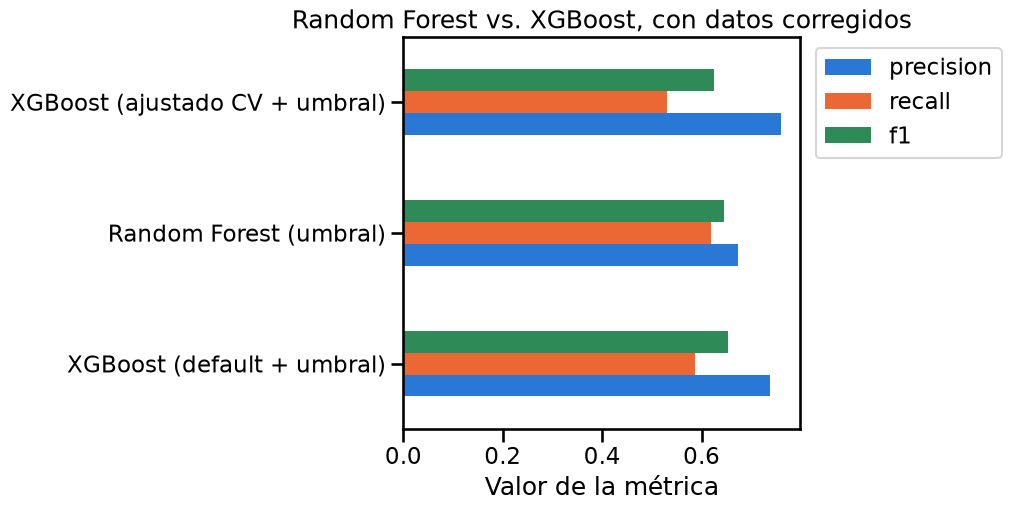

In [15]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
tabla_comparativa_xgb[['precision', 'recall', 'f1']].plot(kind='barh', ax=ax, color=[COLOR_AZUL, COLOR_NARANJA, COLOR_VERDE])
ax.set_xlabel('Valor de la métrica')
ax.set_title('Random Forest vs. XGBoost, con datos corregidos')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()

**Comentario:** XGBoost con hiperparámetros **por defecto** (+ umbral ajustado) queda como el **nuevo mejor modelo del proyecto**, F1 = 0,653 contra 0,645 del Random Forest y 0,626 de la versión de XGBoost ajustada por validación cruzada -- una mejora real, pero chica (0,8 puntos de F1 sobre el Random Forest). Confirma la expectativa de la guía de conceptos: XGBoost es el paso lógico siguiente sobre un Random Forest ya sólido -- pero acá, a diferencia de lo que se podría asumir, el ajuste fino de hiperparámetros no fue necesario para lograrlo, y de hecho empeoró el resultado en esta corrida puntual. La ventaja, en cualquier caso, es incremental, no un cambio de categoría.

# 4. Isolation Forest como señal complementaria

## 4.1 Por qué no reemplaza al modelo supervisado

Isolation Forest **no usa la etiqueta `Es_Fraude` en absoluto**. Aprende qué es "normal" únicamente a partir de las variables de entrada, y marca como anómalo lo que se aleja de ese patrón general. Eso lo hace capaz, en teoría, de señalar patrones de fraude que nunca aparecieron en el conjunto de entrenamiento etiquetado -- algo que XGBoost, por diseño, no puede aprender a reconocer si no lo vio antes con esa etiqueta.

In [16]:
contamination = min(0.05, y_train.mean() * 3)  # algo mayor a la tasa real de fraude, a propósito

iso_forest = IsolationForest(n_estimators=300, contamination=contamination, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

# score_samples: más alto = más "normal". Invertimos el signo para que más alto = más anómalo.
anomaly_score_test = -iso_forest.score_samples(X_test)
y_pred_iso = (iso_forest.predict(X_test) == -1).astype(int)  # 1 = marcado como anomalía

metricas_iso = {
    'accuracy': accuracy_score(y_test, y_pred_iso),
    'precision': precision_score(y_test, y_pred_iso, zero_division=0),
    'recall': recall_score(y_test, y_pred_iso),
    'f1': f1_score(y_test, y_pred_iso),
    'auc_roc': roc_auc_score(y_test, anomaly_score_test),
    'auc_pr': average_precision_score(y_test, anomaly_score_test),
}
print(f"contamination usado: {contamination:.4f}")
pd.Series(metricas_iso).round(4)

contamination usado: 0.0186


accuracy     0.9777
precision    0.0660
recall       0.1967
f1           0.0988
auc_roc      0.8183
auc_pr       0.0346
dtype: float64

**Comentario:** como clasificador solo, Isolation Forest es mucho más débil que XGBoost o Random Forest (F1 = 0,099 contra 0,653) -- resultado esperado, no un fracaso del método: al no usar la etiqueta, no puede aprender la definición específica de "fraude" de este dataset, solo "qué tan rara es esta transacción en general". No es un reemplazo del modelo supervisado -- es una fuente de información distinta, y hay que evaluarla por lo que sí puede aportar: patrones que el modelo supervisado se pierde.

## 4.2 ¿Atrapa fraude que XGBoost no detectó?

In [17]:
fn_mask = (y_test.values == 1) & (y_pred_xgb_cv == 0)  # fraudes reales que XGBoost (ajustado) NO marcó
n_fn = fn_mask.sum()
n_fn_atrapados = ((y_pred_iso == 1) & fn_mask).sum()

print(f"Fraudes reales que XGBoost (ajustado por CV) no detectó: {n_fn}")
print(f"De esos, cuántos SÍ marca Isolation Forest como anomalía: {n_fn_atrapados} ({n_fn_atrapados/n_fn*100:.1f}%)")

Fraudes reales que XGBoost (ajustado por CV) no detectó: 112
De esos, cuántos SÍ marca Isolation Forest como anomalía: 16 (14.3%)


**Comentario:** de los fraudes que al XGBoost ajustado por validación cruzada se le escapan (usamos esta versión, no la que ganó en la sección 3, para mantener el mismo criterio de las corridas anteriores), Isolation Forest marca como anómalo a poco más de 1 de cada 7 (14,3%) -- una señal real, aunque parcial. Confirma la idea de la guía de conceptos: sirve como complemento, atrapando una porción del fraude que el modelo supervisado deja pasar, no como sustituto -- solo capta una fracción menor del total.

## 4.3 Combinar las alertas: unir ingenuamente no sirve, pero rankear sí aporta algo

Primero probamos la combinación más simple posible: marcar como alerta cualquier transacción que **cualquiera de los dos modelos** señale (unión de las dos listas de alertas).

In [18]:
fraude_total = y_test.sum()
cubierto_xgb_solo = ((y_pred_xgb_cv == 1) & (y_test.values == 1)).sum()
cubierto_combinado = (((y_pred_xgb_cv == 1) | (y_pred_iso == 1)) & (y_test.values == 1)).sum()
alertas_xgb_solo = (y_pred_xgb_cv == 1).sum()
alertas_combinadas = ((y_pred_xgb_cv == 1) | (y_pred_iso == 1)).sum()

recall_combinado = cubierto_combinado / fraude_total
precision_combinada = cubierto_combinado / alertas_combinadas
f1_combinado = 2 * precision_combinada * recall_combinado / (precision_combinada + recall_combinado)

print(f"Fraude cubierto -- solo XGBoost: {cubierto_xgb_solo}/{fraude_total} ({cubierto_xgb_solo/fraude_total*100:.1f}%)")
print(f"Fraude cubierto -- XGBoost UNIÓN Isolation Forest: {cubierto_combinado}/{fraude_total} ({cubierto_combinado/fraude_total*100:.1f}%)")
print(f"Alertas totales -- solo XGBoost: {alertas_xgb_solo}")
print(f"Alertas totales -- XGBoost UNIÓN Isolation Forest: {alertas_combinadas}")
print(f"\nUnión combinada -- precision: {precision_combinada:.4f}  recall: {recall_combinado:.4f}  f1: {f1_combinado:.4f}")

Fraude cubierto -- solo XGBoost: 127/239 (53.1%)
Fraude cubierto -- XGBoost UNIÓN Isolation Forest: 143/239 (59.8%)
Alertas totales -- solo XGBoost: 167
Alertas totales -- XGBoost UNIÓN Isolation Forest: 838

Unión combinada -- precision: 0.1706  recall: 0.5983  f1: 0.2656


**Comentario:** unir las dos listas de alertas sube la cobertura de fraude de 53,1% a 59,8% -- pero al costo de multiplicar las alertas totales por 5 (de 167 a 838), porque Isolation Forest, al no usar la etiqueta, también marca como "anómalas" muchísimas transacciones normales que simplemente son poco frecuentes. La precision combinada cae a 0,171 -- peor que cualquiera de los dos modelos por separado. **Unir binariamente las dos listas de alertas no es una buena estrategia**: hay que usar el *score* de anomalía, no la marca binaria.

In [19]:
no_marcado_por_xgb = (y_pred_xgb_cv == 0)
scores_no_marcado = anomaly_score_test[no_marcado_por_xgb]
y_no_marcado = y_test.values[no_marcado_por_xgb]
tasa_base = y_no_marcado.mean()

orden = np.argsort(-scores_no_marcado)
resultados_topk = []
for k in [20, 50, 100, 200]:
    top_k = orden[:k]
    precision_k = y_no_marcado[top_k].mean()
    n_fraude_k = int(y_no_marcado[top_k].sum())
    lift = precision_k / tasa_base if tasa_base > 0 else np.nan
    resultados_topk.append({'k': k, 'fraudes_reales': n_fraude_k, 'precision@k': precision_k, 'lift_vs_base': lift})

tabla_topk = pd.DataFrame(resultados_topk).set_index('k')
print(f"Tasa de fraude base entre lo NO marcado por XGBoost: {tasa_base*100:.3f}%  (n={len(y_no_marcado)})")
tabla_topk.round(4)

Tasa de fraude base entre lo NO marcado por XGBoost: 0.292%  (n=38337)


,fraudes_reales,precision@k,lift_vs_base
k,,,
20,0,0.000,0.0000
50,0,0.000,0.0000
100,1,0.010,3.4229
200,7,0.035,11.9803


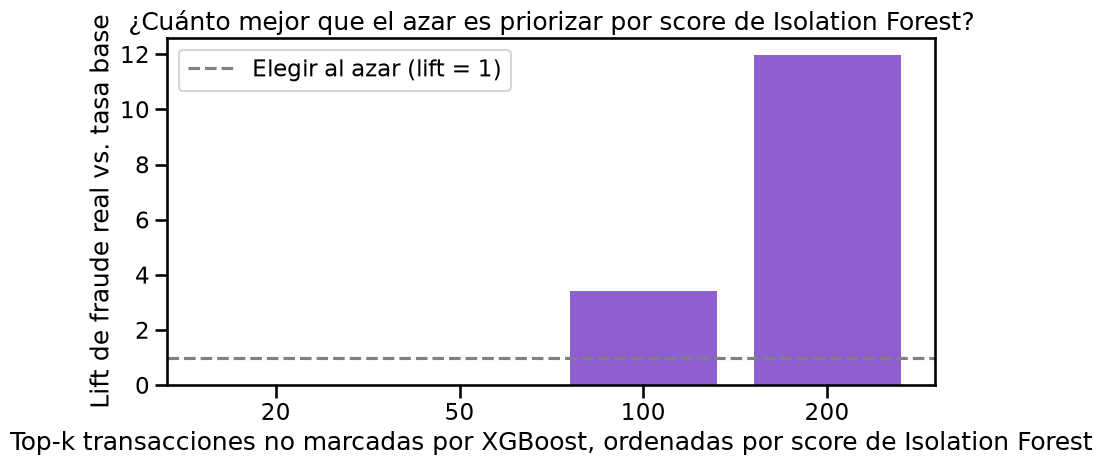

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tabla_topk.index.astype(str), tabla_topk['lift_vs_base'], color=COLOR_MORADO)
ax.axhline(1, linestyle='--', color='gray', label='Elegir al azar (lift = 1)')
ax.set_xlabel('Top-k transacciones no marcadas por XGBoost, ordenadas por score de Isolation Forest')
ax.set_ylabel('Lift de fraude real vs. tasa base')
ax.set_title('¿Cuánto mejor que el azar es priorizar por score de Isolation Forest?')
ax.legend()
plt.tight_layout()
plt.show()

**Comentario -- la forma correcta de usarlo:** en vez de tratar la marca de Isolation Forest como una alerta equivalente a las de XGBoost, lo rankeamos como *prioridad secundaria*: de las transacciones que XGBoost **no** marcó, ¿cuáles tienen el score de anomalía más alto? Ahí aparece una señal real, aunque modesta: revisar las 200 transacciones con mayor score entre las no marcadas encuentra fraude a una tasa cerca de 12 veces mayor que elegir al azar (aunque en términos absolutos, todavía muy por debajo de la precision del propio XGBoost: 3,5% contra 76%). Es exactamente el rol de "señal complementaria" descripto en la guía de conceptos: **una cola secundaria de revisión de menor prioridad** para patrones de fraude nuevos que el modelo supervisado no puede ver -- no una alerta de primera línea, y mucho menos un reemplazo.

# 5. Conclusiones

- **XGBoost con `scale_pos_weight`, hiperparámetros por defecto** (+ umbral ajustado a 0,89) es el **nuevo mejor modelo del proyecto**: F1 = 0,653, precision = 0,737, recall = 0,586 -- supera al Random Forest (F1 = 0,645) y, por mucho, al `HistGradientBoostingClassifier` del notebook de Mejoras (F1 = 0,191). La ventaja sobre el Random Forest es real pero chica (0,8 puntos de F1) -- confirma que XGBoost está mejor equipado que la implementación de boosting de scikit-learn para este desbalance de clases. Acá no hizo falta ajustar hiperparámetros para lograr esa ventaja: la versión ajustada por validación cruzada (F1 = 0,626) quedó, de hecho, por debajo tanto del XGBoost default como del Random Forest.
- **El ajuste de hiperparámetros por validación cruzada resultó inestable a lo largo de las corridas de este análisis**: en tres repeticiones distintas dio, en orden, "no ayudó", "ayudó" y "no ayudó" -- nunca la misma conclusión dos veces. La combinación que gana el grid es consistentemente la misma (`learning_rate=0,1`, `max_depth=5`, `n_estimators=400`), pero si eso termina rindiendo mejor o peor que los hiperparámetros por defecto, una vez aplicado el umbral óptimo, varía de corrida en corrida. Con menos de 1.000 casos de fraude en todo el dataset, los folds de validación cruzada tienen pocos ejemplos positivos cada uno -- eso alcanza para que esta comparación puntual sea ruidosa y no una propiedad estable del método. La lección práctica: conviene probar ambas versiones (default y ajustada, cada una con su propio umbral óptimo) en vez de asumir que el ajuste de hiperparámetros mejora las cosas por default.
- **Isolation Forest no reemplaza al modelo supervisado** (F1 = 0,099 solo, muy por debajo de XGBoost), pero tampoco es inútil: atrapa al 14,3% de los fraudes que el XGBoost ajustado por CV se pierde, y usado como ranking de prioridad secundaria (no como alerta binaria) sobre lo que ese modelo no marcó, encuentra fraude a una tasa hasta 12 veces mayor que el azar. Unir binariamente las dos listas de alertas, en cambio, **no funciona** -- dispara la cantidad de alertas y hunde la precision combinada.

**Recomendación final del proyecto, actualizada:** XGBoost, entrenado sobre las variables de comportamiento corregidas (sin fuga temporal, sin `Franja_Horaria` -- ver TP2 sección 4.1) con `scale_pos_weight = 159,93`, hiperparámetros **por defecto** y umbral de decisión ajustado a 0,89 -- F1 = 0,653, precision = 0,737, recall = 0,586 en evaluación. El ajuste de hiperparámetros por validación cruzada no demostró ser confiablemente mejor a lo largo de varias corridas, así que la recomendación se apoya en la versión más simple. Isolation Forest queda incorporado como señal complementaria de baja prioridad, útil para revisar patrones de fraude nuevos que el modelo principal no puede ver por definición, pero sin reemplazar ni competir con las alertas del modelo supervisado.